### Text Preprocessing & Feature Engineering

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import re, os, pickle, warnings
from collections import Counter
warnings.filterwarnings('ignore')

# NLP
import nltk
import spacy
from nltk.corpus import stopwords
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)


# Feature engineering
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from gensim.models import Word2Vec

# Plot style
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

COLORS = {'Positive': '#1D9E75', 'Neutral': '#EF9F27', 'Negative': '#E24B4A'}

os.makedirs('../outputs', exist_ok=True)
os.makedirs('../models', exist_ok=True)

# Load spaCy English model
nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

print("✅ All imports done")

✅ All imports done


In [ ]:
# import sys
# !{sys.executable} -m spacy download en_core_web_sm

     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     --- ------------------------------------ 1.0/12.8 MB 4.2 MB/s eta 0:00:03
     ------ --------------------------------- 2.1/12.8 MB 4.5 MB/s eta 0:00:03
     --------- ------------------------------ 3.1/12.8 MB 4.7 MB/s eta 0:00:03
     ------------- -------------------------- 4.5/12.8 MB 5.0 MB/s eta 0:00:02
     --------------------- ------------------ 6.8/12.8 MB 6.2 MB/s eta 0:00:01
     --------------------------- ------------ 8.9/12.8 MB 6.9 MB/s eta 0:00:01
     ---------------------------------- ----- 11.0/12.8 MB 7.4 MB/s eta 0:00:01
     ---------------------------------------- 12.8/12.8 MB 7.5 MB/s  0:00:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
df = pd.read_csv("D:\hilearn\Machine Learning\Project\Customer Review\data\Reviews.csv")


# Check what columns exist
print("Columns:", df.columns.tolist())
print("Shape:", df.shape)

Columns: ['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text']
Shape: (568454, 10)


In [11]:


# Recreate sentiment column if missing
if 'sentiment' not in df.columns:
    def map_sentiment(score):
        if score >= 4:   return 'Positive'
        elif score == 3: return 'Neutral'
        else:            return 'Negative'
    df['sentiment'] = df['Score'].apply(map_sentiment)
    print("✅ sentiment column recreated")

# Sample and check
df = df.sample(n=50_000, random_state=42).reset_index(drop=True)
print(f"Working dataset: {df.shape[0]:,} rows")
print(df['sentiment'].value_counts())
df.head(3)

✅ sentiment column recreated
Working dataset: 50,000 rows
sentiment
Positive    39105
Negative     7104
Neutral      3791
Name: count, dtype: int64


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,sentiment
0,165257,B000EVG8J2,A1L01D2BD3RKVO,"B. Miller ""pet person""",0,0,5,1268179200,Crunchy & Good Gluten-Free Sandwich Cookies!,Having tried a couple of other brands of glute...,Positive
1,231466,B0000BXJIS,A3U62RE5XZDP0G,Marty,0,0,5,1298937600,great kitty treats,My cat loves these treats. If ever I can't fin...,Positive
2,427828,B008FHUFAU,AOXC0JQQZGGB6,Kenneth Shevlin,0,2,3,1224028800,COFFEE TASTE,A little less than I expected. It tends to ha...,Neutral


In [12]:
SW = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()                          # lowercase
    text = re.sub(r'<.*?>', ' ', text)                # remove HTML tags
    text = re.sub(r'http\S+|www\S+', ' ', text)       # remove URLs
    text = re.sub(r"[^a-z\s']", ' ', text)            # keep only letters
    text = re.sub(r'\s+', ' ', text).strip()          # collapse whitespace
    return text

# Apply cleaning
df['clean_text'] = df['Text'].apply(clean_text)

# Verify — show before/after
sample = df[['Text', 'clean_text']].sample(3, random_state=1)
for _, row in sample.iterrows():
    print("RAW:  ", row['Text'][:120])
    print("CLEAN:", row['clean_text'][:120])
    print()

RAW:   I absolutely LOVE the taste of these Cinnamon Brown Sugar Roasted Almonds - in fact I just can't stop at one pack!!!  I 
CLEAN: i absolutely love the taste of these cinnamon brown sugar roasted almonds in fact i just can't stop at one pack i only w

RAW:   This granola is almost too good.  The oat clusters are mostly all in the 1/2 inch range and they taste exceptionally goo
CLEAN: this granola is almost too good the oat clusters are mostly all in the inch range and they taste exceptionally good defi

RAW:   I discovered this granola in Florida and buy it regularly when I am there.  While in PA I order it online through Amazon
CLEAN: i discovered this granola in florida and buy it regularly when i am there while in pa i order it online through amazon s



In [13]:
def lemmatize_batch(texts, batch_size=500):
    """Lemmatize using spaCy pipe — much faster than row-by-row."""
    results = []
    for doc in nlp.pipe(texts, batch_size=batch_size):
        tokens = [
            token.lemma_
            for token in doc
            if token.is_alpha             # letters only
            and not token.is_stop         # remove stopwords
            and len(token.lemma_) > 2     # skip very short words
        ]
        results.append(' '.join(tokens))
    return results

print("Lemmatizing... (this takes ~3 minutes for 50k rows)")
df['lemmatized'] = lemmatize_batch(df['clean_text'].tolist())

print("✅ Done!")
# Show example
for _, row in df[['clean_text','lemmatized']].sample(2, random_state=5).iterrows():
    print("CLEAN:      ", row['clean_text'][:100])
    print("LEMMATIZED: ", row['lemmatized'][:100])
    print()

Lemmatizing... (this takes ~3 minutes for 50k rows)
✅ Done!
CLEAN:       tastes great excellent value when purchased in the oz bottle i served this product to friends and al
LEMMATIZED:  taste great excellent value purchase bottle serve product friend enjoy fresh berry taste zero cal ca

CLEAN:       i love this soup it's really great it's just a wonderful blend of creamy tomato with actual chunks o
LEMMATIZED:  love soup great wonderful blend creamy tomato actual chunk tomato eat entire meal wish high sodium h



In [16]:
from sklearn.model_selection import train_test_split

# Label encode
label_map = {'Positive': 2, 'Neutral': 1, 'Negative': 0}
df['label'] = df['sentiment'].map(label_map)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    df['lemmatized'], df['label'],
    test_size=0.2, random_state=42, stratify=df['label']
)

print(f"Train: {len(X_train):,}  |  Test: {len(X_test):,}")
print(f"Train class distribution:\n{pd.Series(y_train).value_counts()}")

# Save preprocessed data
df.to_csv(r"D:\hilearn\Machine Learning\Project\Customer Review\data\reviews_preprocessed.csv", index=False)
print("\n✅ Saved reviews_preprocessed.csv")

Train: 40,000  |  Test: 10,000
Train class distribution:
label
2    31284
0     5683
1     3033
Name: count, dtype: int64

✅ Saved reviews_preprocessed.csv


In [ ]:
bow_vectorizer = CountVectorizer(
    max_features=20_000,    # keep top 20k words by frequency
    min_df=5,               # ignore words in fewer than 5 docs
    max_df=0.90,            # ignore words in more than 90% of docs
    ngram_range=(1, 2),     # unigrams + bigrams
)

X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow  = bow_vectorizer.transform(X_test)

print(f"BoW matrix shape (train): {X_train_bow.shape}")
print(f"Vocabulary size: {len(bow_vectorizer.vocabulary_):,}")
print(f"Matrix sparsity: {1 - X_train_bow.nnz / (X_train_bow.shape[0]*X_train_bow.shape[1]):.4%}")

# Save vectorizer 
with open('../models/bow_vectorizer.pkl', 'wb') as f:
    pickle.dump(bow_vectorizer, f)
print("✅ BoW vectorizer saved")

BoW matrix shape (train): (40000, 20000)
Vocabulary size: 20,000
Matrix sparsity: 99.8191%
✅ BoW vectorizer saved


In [18]:
tfidf_vectorizer = TfidfVectorizer(
    max_features=20_000,
    min_df=5,
    max_df=0.90,
    ngram_range=(1, 2),
    sublinear_tf=True,      # apply log(1+tf) — dampens very high counts
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf  = tfidf_vectorizer.transform(X_test)

print(f"TF-IDF matrix shape (train): {X_train_tfidf.shape}")

# Save vectorizer for Week 3
with open('../models/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf_vectorizer, f)
print("✅ TF-IDF vectorizer saved")

TF-IDF matrix shape (train): (40000, 20000)
✅ TF-IDF vectorizer saved


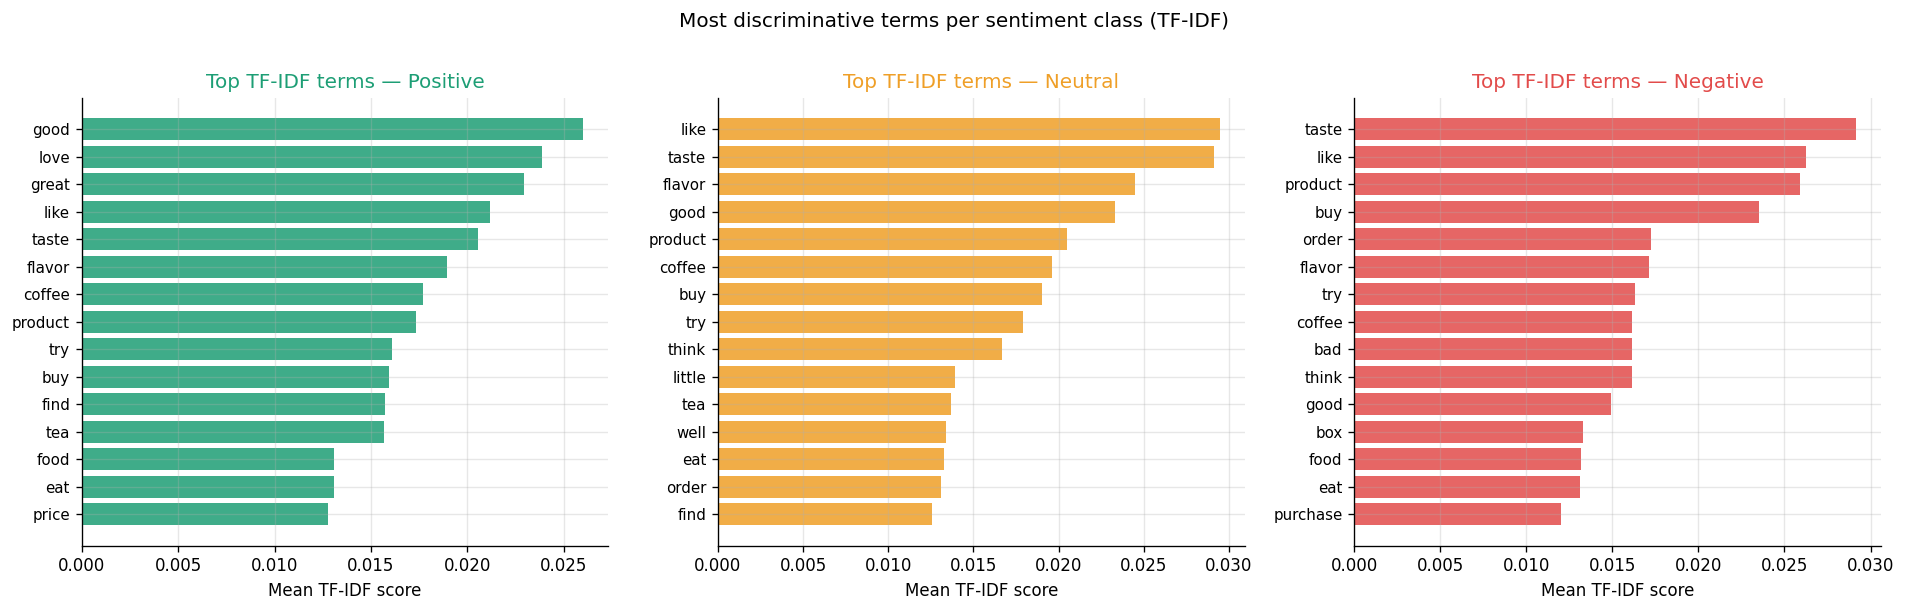

In [20]:
feature_names = tfidf_vectorizer.get_feature_names_out()
label_names   = {2: 'Positive', 1: 'Neutral', 0: 'Negative'}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

y_train_arr = y_train.values  # ← convert Series to numpy array

for ax, (label_id, label_name) in zip(axes, label_names.items()):
    mask = y_train_arr == label_id   # ← use numpy array here
    mean_tfidf = np.asarray(X_train_tfidf[mask].mean(axis=0)).flatten()
    top_idx    = mean_tfidf.argsort()[-15:]
    top_terms  = feature_names[top_idx]
    top_scores = mean_tfidf[top_idx]

    ax.barh(top_terms, top_scores,
            color=COLORS[label_name], alpha=0.85, edgecolor='none')
    ax.set_title(f'Top TF-IDF terms — {label_name}',
                 color=COLORS[label_name], fontsize=12)
    ax.set_xlabel('Mean TF-IDF score')
    ax.tick_params(axis='y', labelsize=9)

plt.suptitle('Most discriminative terms per sentiment class (TF-IDF)', y=1.01)
plt.tight_layout()
plt.savefig('../outputs/06_tfidf_top_terms.png', bbox_inches='tight')
plt.show()

In [21]:
# Word2Vec needs tokenized lists, not strings
train_tokens = [text.split() for text in X_train]
test_tokens  = [text.split() for text in X_test]

w2v_model = Word2Vec(
    sentences=train_tokens,
    vector_size=100,     # each word → 100-dim vector
    window=5,            # context window: 5 words left+right
    min_count=5,         # ignore words appearing < 5 times
    workers=4,           # parallel threads
    epochs=10,
    seed=42,
)

print(f"Vocabulary size: {len(w2v_model.wv):,} words")
print(f"Vector size: {w2v_model.vector_size}")

# Quick sanity check — similar words to 'delicious'
print("\nWords similar to 'delicious':")
print(w2v_model.wv.most_similar('delicious', topn=5))

# Save model
w2v_model.save('../models/word2vec.model')
print("\n✅ Word2Vec model saved")

Vocabulary size: 9,408 words
Vector size: 100

Words similar to 'delicious':
[('yummy', 0.7390725016593933), ('tasty', 0.7120563387870789), ('fantastic', 0.6316744685173035), ('wonderful', 0.6040700674057007), ('awesome', 0.6031683683395386)]

✅ Word2Vec model saved
